## `I. Transfer learning (en vision)`
L’apprentissage par transfert consiste à réutiliser un modèle déjà entraîné sur une première tâche pour en apprendre une nouvelle, proche, au lieu de repartir de zéro.
#### _`1.1 Objectif`_
- Utilisation d'un réseau de neurones convolutif (ConvNet) comme extracteur de caractéristiques fixes. 
- Prendre un ConvNet pré-entraîné sur ImageNet, 
- Supprimer la dernière couche entièrement connectée 
- Les sorties correspondent aux scores des 1 000 classes pour une tâche différente, comme ImageNet, 
- Traiter le reste du ConvNet comme un extracteur de caractéristiques fixes pour le nouveau jeu de données.
#### _`1.2 Documentation`_   
- Apprentissage par transfert d'un réseau de neurones convolutif pour la classification d'images.
   - Modifié de https://pytorch.org/tutorials/beginner/transfer_learning_tutorial.html 
- Pour en savoir plus concernant les critères permettant de choisir l'une ou l'autre approche. 
   - voir par exemple https://cs231n.github.io/transfer-learning/

#### _`1.3 Idée de base`_
Un modèle a appris à classifier des représentations sur une tâche de type ImageNet / ConvNet, le but consiste à adapter ce modèle à une tâche B liée.
- par ex. classifier des types de tumeurs, des pièces mécaniques, des races de chiens avec peu de données.
- On _transfère_ les connaissances de A vers B en réutilisant ce que le modèle sait sur un nouveau problème.
- Cette ré-utilisation permet de réduire le temps et le coût d’entraînement en deep learning.
- Cela permet également de mieux généraliser quand on a peu de données pour la tâche cible.
#### _`1.4 Principaux scénarios d'apprentissage par transfert`_
##### _`1.4.1 Fine-tuning du réseau`_ 
- Plutot qu'une initialisation aléatoire, on repart du modèle pré‑entraîné 
- on continue d’entraîner tout ou partie des couches sur la nouvelle base de données, 
- souvent avec un faible learning rate. 
##### _`1.4.2 Feature extraction`_ 
- Dans ce cas, on conserve le backbone pré‑entraîné (par ex. ConvNeXt sur ImageNet), 
- nous figeons les poids pour tout le réseau, à l'exception de la dernière couche fully connected
- la dernière couche entièrement connectée, en charge de la classification
- cette couche entièrement connectée est remplacée par une nouvelle couche avec des poids aléatoires 
- cette seule couche de sortie adaptée à la nouvelle tâche est entraînée 
##### _`1.4.3 Domain adaptation / transfert transductif`_
- Transfert transductif = transfert learning orienté domaine cible précis, 
- avec accès aux données cibles (souvent non étiquetées) dès l’entraînement, 
- sans chercher à généraliser au‑delà de ce jeu cible
- même tâche mais distribution de données différente 
- par ex. mêmes classes objet, mais images prises dans un autre domaine : médical, industriel, etc..
#### _`1.5 Quand et comment effectuer un réglage fin`_
_1. Le nouveau jeu de données est petit et similaire au jeu de données original_
- Il est déconseillé d'affiner le réseau de neurones convolutif (ConvNet) afin d'éviter le surapprentissage.
_2. Le nouveau jeu de données est volumineux et similaire au jeu de données original_
- Disposant de davantage de données, nous pouvons être plus confiants quant au risque de surapprentissage.
_3. Le nouveau jeu de données est petit mais très différent du jeu de données original_
- Vue la petite taille, il est préférable d'entraîner uniquement un classificateur linéaire.
- Entraîner le classificateur SVM à partir des activations situées plus tôt dans le réseau.
_4. Le nouveau jeu de données est volumineux et très différent du jeu de données original_
- On pourrait s'attendre à entraîner un réseau de neurones convolutif (ConvNet) à partir de zéro.
- Il est souvent plus avantageux d'initialiser les poids avec ceux d'un modèle pré-entraîné.
:::

In [1]:
# License: BSD
# Author: Sasank Chilamkurthy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import torch.backends.mps as mps
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
from PIL import Image
from tempfile import TemporaryDirectory

print(mps.is_available())
plt.ion()   # interactive mode

True


##### _`Remarque`_
_`Basée sur une énumération ConvNeXt_Tiny_Weights`_ 
- ConvNeXt_Tiny_Weights.DEFAULT
- Pointe vers le jeu de poids recommandé (actuellement _IMAGENET1K_V1_), 
- Si les auteurs changent le « meilleur » checkpoint, le code suivra automatiquement.
- Contient des méta‑données (transforms recommandées, catégories, etc.), utiles pour préparer les images.

In [2]:
# manière 1 :
# C’est l’ancienne interface de torchvision, maintenue pour compatibilité, 
# mais considérée comme « legacy ». 
# model = convnext_tiny(weights="IMAGENET1K_V1")

In [3]:
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
# manière 2 : 
weights = ConvNeXt_Tiny_Weights.DEFAULT
model = convnext_tiny(weights=weights)

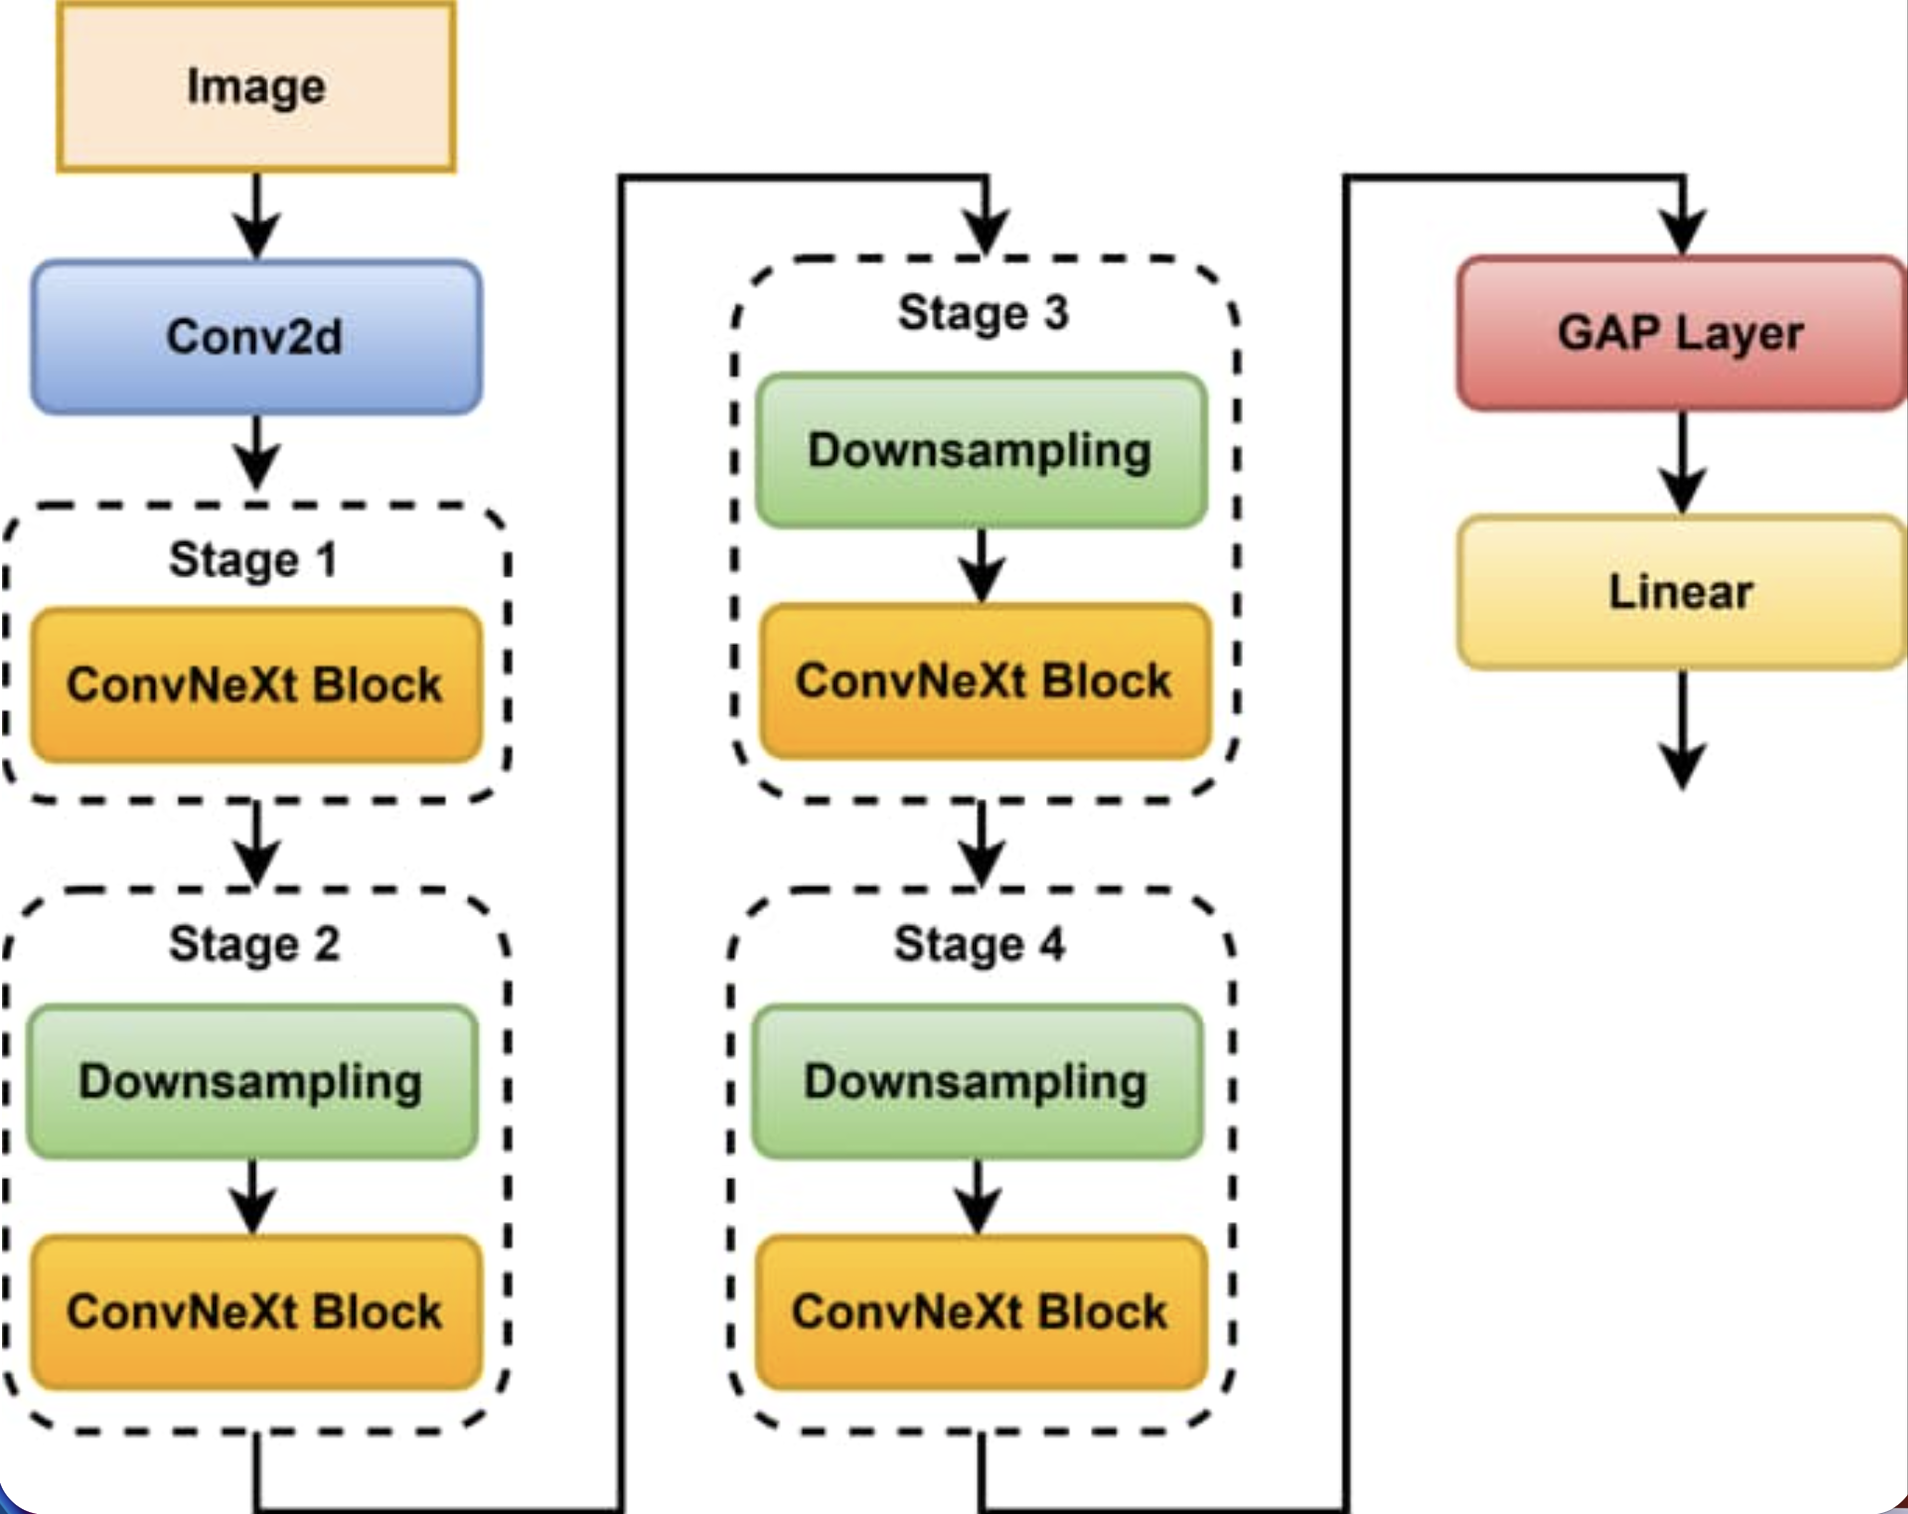

In [4]:
path="/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_APPAUT/2026_CNN_Modernes/images"
filename="convenext.png"
from IPython.display import Image, display
display(Image(os.path.join(path, filename), width=400))

_`Dans ConvNeXt (et CNN en général), le downsampling est caractérisé par :`_ 
- une couche qui réduit la résolution spatiale (H×W) en utilisant un stride > 1, 
- souvent avec un kernel qui “mosaïque” l’image.

_`Caractéristique clé :`_ 
- stride > 1 ⇒ réduction de résolution, 
- augmentation du nombre de canaux ⇒ plus de capacité de représentation sur une grille plus petite.

_model.eval()_ 
 - Désactive dropout, 
 - Met batchnorm en mode inférence, etc., 
 - Indispensable pour l’inférence.
 - Requis pour pré-traitement, 
   - mettre au format « recommandé par les weights » 
   - les transforms inclus dans ConvNeXt_Tiny_Weights

In [5]:
# Set model to eval mode
model.eval()
print(model)

ConvNeXt(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=96, out_features=384, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=384, out_features=96, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=

#### _`2.1 stages hiérarchiques pour ConvNeXt‑T`_
Pour ConvNeXt‑Tiny, hidden_sizes = [96, 192, 384, 768] → largeur (nb de canaux / filtres) des 4 stages.

| _Stage_   | _Résolution typique_   | _Canaux C_   | _Blocs B_   |
|-----------|------------------------|--------------|-------------|
| 1         | 56×56                  | 96           | 3           |
| 2         | 28×28                  | 192          | 3           |
| 3         | 14×14                  | 384          | 9           |
| 4         | 7×7                    | 768          | 3           |

__Pour le stem Conv2d(3, 96, kernel_size=4, stride=4)__
- L’image d’entrée a 3 canaux (R, G, B).
- La couche possède 96 filtres, chacun de taille 3×4×4 (un petit cube qui couvre les 3 canaux sur un patch 4×4).
 - Chaque filtre balaye toute l’image, et produit une feature map 2D en sortie.
__Donc au total :__
- les 96 filtres effectuent chacun une convolution sur les 3 canaux de l’image (en combinant R, G, B dans un même filtre),
- ce qui donne 96 feature maps, soit une sortie de forme (batch, 96, 56, 56) pour une image (batch, 3, 224, 224)
__Cette couche contient un tenseur de poids weight de shape__ : (out_channels, in_channels, kH, kW) = (96, 3, 4, 4).
__Il y a 96 kernels 3D différents__: chacun a 3 “sous‑filtres” 2D 4×4 un par canal d’entrée, et la sortie de ce kernel est la somme des convolutions sur les 3 canaux + un biais.
__Les valeurs de ces filtres ne sont pas spécifiées dans l’appel à Conv2d :__ elles sont initialisées (aléatoirement ou via une init par défaut) et apprises pendant l’entraînement comme n’importe quels poids de réseau.

#### `2.2. Macro‑architecture (stages et dimensions)`
ConvNeXt garde une structure ResNet‑like en 4 stages, avec downsampling entre eux.
_`Input / Stem`_
- En vision (CNN modernes), le stem est le bloc d’entrées du réseau.
- Convolution 4×4, stride 4, réduit l’image 224×224→56×56 et passe de 3 à 1 canal (96 pour ConvNeXt‑T).
_`Équivaut à un “patch embedding” façon ViT`_
__ViT Vision Transformer__ 
- C'est une architecture qui applique le principe des Transformers 
- Self‑attention, MLP, LayerNorm… à des images, 
- En remplaçant la séquence de mots par une séquence de patchs d’image.
__Patch embedding__ 
- On découpe l’image en patchs non chevauchants (par ex. 16×16).
- Chaque patch est aplati (tous ses pixels) puis projeté linéairement dans un vecteur de dimension D 
- C’est un token d’entrée du Transformer (comme un mot encodé).
- La conv 4×4 stride 4 de ConvNeXt fait presque la même chose :
  - stride 4 → patchs 4×4, non chevauchants ;
  - 3 canaux → 96 canaux = vecteur de dimension 96 par patch ;
  - la grille 56×56 est exactement une carte de patchs, 
  - que l'on peut interpréter comme une séquence de 56×56 tokens.

:::
_`Downsampling entre stages :`_ 
- 3 couches de downsampling séparées, 
- chacune est une conv 2×2, stride 2, 
- qui divise la résolution par 2 et double les canaux $C_i → C_{i+1}$
_`Head de classification :`_ 
- LayerNorm sur les features finaux, 
- global average pooling (ou global mean sur les dimensions spatiales), 
- puis Linear vers les classes.
:::


#### `2.3 Bloc ConvNeXt (la brique de base)`
_`1. Entrée et premiers patchs`_
(0): Conv2dNormActivation(
   - (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
   - (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True))
`Convolution 4×4 stride 4` : convertit l’image (3 canaux) en 96 cartes de caractéristiques, en découpant implicitement l’image en « patchs » 4×4 (comme un patch embedding de ViT).
`LayerNorm2d` applique une normalisation par couche sur les 96 canaux, ce qui stabilise l’optimisation et remplace le duo BatchNorm + ReLU des ResNet classiques.
_`2. Blocs ConvNeXt (CNBlock)`_ 
CNBlock( (block): Sequential(
 - (0): Conv2d(C, C, kernel_size=7, padding=3, groups=C) -> depthwise par canal
 - (1): Permute()  -> (N, C, H, W) -> (N, H, W, C)
 - (2): LayerNorm((C,), ...)
 - (3): Linear(C, 4C) -> MLP expansion de type Vision Transformer,appliqué à chaque position spatiale (h,w)
 - (4): GELU()
 - (5): Linear(4C, C) -> MLP projection de type Vision Transformer
 - (6): Permute() ).  -> retour (N, C, H, W)
  (stochastic_depth): StochasticDepth(p=..., mode=row)).   

`Conv2d(... groups=C)` : 
 - Convolution depthwise 7×7 par canal (comme une attention locale large, mais purement conv).
 - Pour chaque canal, un filtre 7×7 « regarde autour » de chaque pixel et combine ses voisins.
 - Avec un kernel 7×7, la valeur de sortie en (h,w) est une combinaison linéaire des 49 pixels.
 - groups = C (depthwise) filtre indépendants par canal, aucune combinaison entre canaux dans cette conv.
 - Le mélange d’information entre canaux est reporté sur des couches suivantes (par ex. conv 1×1 / MLP).
 - l’information devient plus lissée et contextuelle spatialement.
   - peut apprendre un effet de flou / lissage proche d’un filtre gaussien.
   - peut au contraire apprendre un détecteur de contours (Sobel‑like, Laplacien, etc.).
   - peut capter des textures ou motifs plus larges rayures, taches, motifs répétitifs,.. 
`StochasticDepth` : 
 - drop de chemin résiduel aléatoirement pour régulariser en profondeur. 
 - La probabilité augmente avec la profondeur (0 → 0.1).
_`Chaque CNBlock a un résidu du type x + drop(block(x)) même s’il n’apparaît pas`_
__Résumé du flux dans un bloc ConvNeXt__
`Conv2d(..., groups=C, kernel=7) :` 
 - depthwise, agrandit le contexte spatial par canal, sans les mélanger.
`Permute + LayerNorm + Linear(GELU) + Linear + Permute :` 
- le MLP fait le mixing entre canaux.
- Conv2d(96→192, kernel=2, stride=2) downsampling classiques changent la résolution et le nombre de canaux.

`convolution depthwise (grouped conv extrême)`
- 192 groupes, chaque canal d’entrée est filtré par son kernel 7×7 sans mélange avec les autres canaux.
- C’est la “depthwise conv” typique des ConvNeXt blocks (conv large kernel, par‑canal). 
- Ce n’est pas une couche de downsampling, mais une convolution depthwise à large noyau qui élargit le champ réceptif sans changer la résolution.
- Le mélange entre canaux se fait ensuite par des couches 1×1 (pointwise conv) / MLP, pas par cette conv depthwise

`weights.transforms()` 
 - renvoit la pipeline de pré‑traitement officielle à appliquer aux images pour qu’elles soient compatibles avec les poids pré‑entraînés (ici, ConvNeXt_Tiny_Weights.IMAGENET1K_V1)

https://pytorch.org/vision/main/models/generated/torchvision.models.convnext_tiny.html#torchvision.models.convnext_tiny


In [6]:
preprocess = weights.transforms()
# img_tensor = preprocess(pil_image)

`preprocessing operations:` Effectue les opérations de prétraitement suivantes : 
 - elles acceptent les objets image PIL.Image, 
 - qu'ils soient par lots ou uniques
 - les images sont redimensionnées à l'aide de interpolation=InterpolationMode.BILINEAR,
 - puis un recadrage central est effectué crop_size=[224]. 
 - enfin, les valeurs sont d'abord mises à l'échelle [0.0, 1.0] , 
 - puis normalisées à l'aide de mean=[0.485, 0.456, 0.406] et std=[0.229, 0.224, 0.225].

#### `III. Charger les données`

- Nous utilisons torchvision et torch.utils.data pour charger les données.
- Le problème à résoudre est d'entrainer un modèle pour classifier **fourmis** et **abeilles**. 
- Nous disposons d'environ 120 images d'entraînement pour les fourmis et les abeilles. 
- Il y a 75 images de validation pour chaque classe. 
- Ce jeu de données (issu d'ImageNet) est trop petit pour entraîner un réseau profond à partir de zéro.
- En utiliserant l'apprentissage par transfert, nous devrions généraliser raisonnablement bien.

In [7]:
#%wget https://download.pytorch.org/tutorial/hymenoptera_data.zip

In [8]:
#%unzip -q hymenoptera_data.zip

`cudnn.benchmark = True` 
 - Active le mode benchmark de cuDNN
 - PyTorch teste plusieurs algos de convolution au début et choisit le plus rapide 
 - pour la config (modèle + taille d’input) afin d’accélérer l’entraînement/inférence.
 - Au premier appel des convolutions, cuDNN essaie différentes implémentations (Winograd, FFT, GEMM, etc.), 
 - Mesure les temps, puis mémorise l’algo le plus rapide pour chaque couche.

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
import copy
# active le mode benchmark de cuDNN
cudnn.benchmark = True

In [10]:
data_dir="/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_APPAUT/2026_CNN_Modernes/hymenoptera_data"
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),preprocess) for x in ['train', 'val']}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x],  # type: ignore
                        batch_size=4,shuffle=True, num_workers=2) 
                        for x in ['train', 'val']} 

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
print(dataset_sizes)
class_names = image_datasets['train'].classes
print(class_names)

device = torch.device("mps:0" if torch.backends.mps.is_available() else "cpu")

model = model.to(device)
print(device)

{'train': 244, 'val': 153}
['ants', 'bees']
mps:0


#### `3.1. Visualisation`

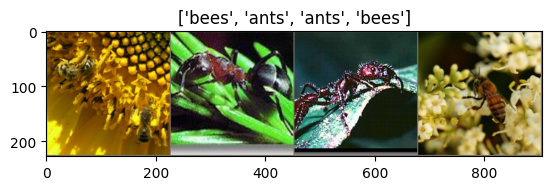

In [11]:
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated

# Get a batch of training data
inputs, classes = next(iter(dataloaders['train']))
# Make a grid from batch
out = torchvision.utils.make_grid(inputs)
imshow(out, title=[class_names[x] for x in classes])

#### `3.2 Testons le modèle`

In [12]:
def visualize_predictions(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    # fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            max_values, preds = torch.max(outputs, 1)

            # break
            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                category_name = weights.meta["categories"][preds[j]]
                # print(f"{category_name}: {100 * torch.sigmoid(max_values[j]).item():.1f}%")
                ax.set_title(f'predicted: {category_name} {100 * torch.sigmoid(max_values[j]).item():.1f}%')
                inp = inputs.cpu().data[j].numpy().transpose((1, 2, 0))
                mean = np.array([0.485, 0.456, 0.406])
                std = np.array([0.229, 0.224, 0.225])
                inp = std * inp + mean
                inp = np.clip(inp, 0, 1)
                plt.imshow(inp)

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

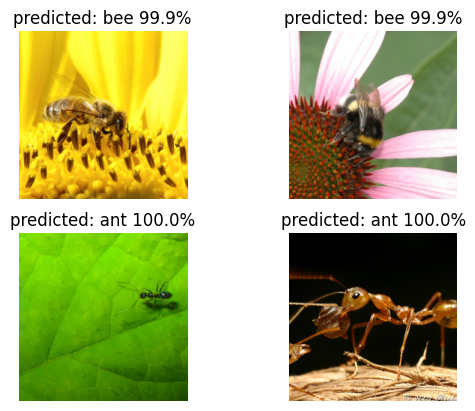

In [13]:
visualize_predictions(model, num_images=4)

On voit que les prédictions sont presque toujours exactes... Sauf que le modèle prédit 1000 classes, donc parfois "nid d'abeilles" ("honeycomb") au lieu d'abeille tout court...

### `IV. Une fonction de train générique`

In [14]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data.
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # remet à zéro les parametres gradients accumulés avant un nouveau backward.
                optimizer.zero_grad()

                # forward
                # track history if only in train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()  # rétropropagation : calcule les gradients dL/dθ
                        optimizer.step() # met à jour les paramètres avec ces gradients

                # statistics
                # inputs.size(0) = taille du batch. 
                # loss est souvent une moyenne par batch (ex. CrossEntropyLoss retourne la moyenne sur le batch).
                # On multiplie pour revenir à une somme de loss sur le batch, puis on additionne à running_loss
                running_loss += loss.item() * inputs.size(0) # loss totale 
                # preds et labels sont des tenseurs de taille (batch_size,).
                # preds == labels.data donne un booléen par exemple,
                # torch.sum(...) donne le nombre de bonnes prédictions dans le batch, 
                # que l’on ajoute à running_corrects
                running_corrects += torch.sum(preds == labels.data)
            if phase == 'train':
                # fait avancer d’un cran le scheduler de learning rate et 
                # met à jour le lr de l’optimizer selon la politique choisie.
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.float() / dataset_sizes[phase] # type: ignore

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # deep copy the model
            # Sert à sauvegarder les meilleurs poids du modèle selon l’accuracy de validation.
            # Si l’accuracy de cette époque est meilleure que best_acc, on met à jour best_acc et 
            # On stocke un snapshot complet des poids dans best_model_wts.
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:4f}')

    # load best model weights
    model.load_state_dict(best_model_wts)
    return model

### `4.1. Visualiser des prédictions sur deux classes`

In [15]:
def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[preds[j]]}')
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

### `4.2. Apprentissage par transfert 1` 
#### `finetuning`

In [16]:
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
# manière 2 : 
weights = ConvNeXt_Tiny_Weights.DEFAULT
model = convnext_tiny(weights=weights)
model_ft = model
print("La couche classifier de ConvNext :\n",model.classifier)
# récupérer la dimension des inputs à la couche de classification de ConvNeXt :
num_ftrs = model.classifier[2].in_features
print("la dimension des inputs à la couche de classification de ConvNext : ",num_ftrs)
# remplacer la couche linéaire du classifieur par un nouvelle couche à deux neurones de sortie : 
model.classifier[2] = nn.Linear(num_ftrs, 2)
model_ft = model_ft.to(device)

criterion = nn.CrossEntropyLoss()

# Tous les poids vont être optimisés ici : 
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

# Diminuer LR d'un facteur 0.1 chaque 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

La couche classifier de ConvNext :
 Sequential(
  (0): LayerNorm2d((768,), eps=1e-06, elementwise_affine=True)
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): Linear(in_features=768, out_features=1000, bias=True)
)
la dimension des inputs à la couche de classification de ConvNext :  768


### `4.3. Apprentissage par transfert 2`
#### `Extraction de features et classifieur`

In [17]:
model_ft = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler,num_epochs=3)

Epoch 0/2
----------
train Loss: 0.4433 Acc: 0.7500
val Loss: 0.2859 Acc: 0.8431

Epoch 1/2
----------
train Loss: 0.1463 Acc: 0.9344
val Loss: 0.0624 Acc: 0.9739

Epoch 2/2
----------
train Loss: 0.1650 Acc: 0.9426
val Loss: 0.2476 Acc: 0.9346

Training complete in 2m 53s
Best val Acc: 0.973856


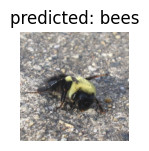

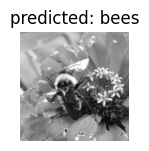

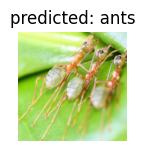

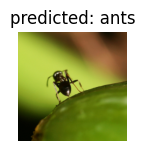

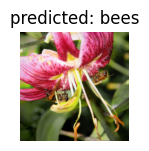

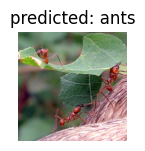

In [19]:
visualize_model(model_ft)

plt.ioff()
plt.show()

In [ ]:
model_extract = model
# récupérer la dimension des inputs à la couche de classification de ConvNeXt : 
num_ftrs = model.classifier[2].in_features

# "geler" les poids de model_extract : 
# geler tous les poids
for param in model_extract.parameters():
    param.requires_grad = False

# remplacer la couche linéaire du classifieur par un nouvelle couche à deux neurones de sortie : 
model_extract.classifier[2] = nn.Linear(num_ftrs, 2)
model_extract = model_extract.to(device)

criterion = nn.CrossEntropyLoss()

# Tous les poids vont être optimisés ici : 
optimizer_ft = optim.SGD(model_extract.parameters(), lr=0.001, momentum=0.9)

# Diminuer LR d'un facteur 0.1 chaque 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

768


In [21]:
model_ft = train_model(model_extract, criterion, optimizer_ft, exp_lr_scheduler,num_epochs=3)

Epoch 0/2
----------
train Loss: 0.2137 Acc: 0.8975
val Loss: 0.0812 Acc: 0.9608

Epoch 1/2
----------
train Loss: 0.0521 Acc: 0.9918
val Loss: 0.0670 Acc: 0.9542

Epoch 2/2
----------
train Loss: 0.0475 Acc: 0.9877
val Loss: 0.0706 Acc: 0.9673

Training complete in 1m 19s
Best val Acc: 0.967320


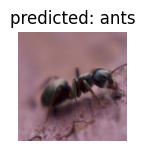

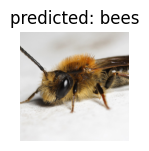

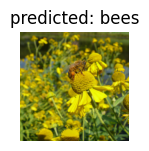

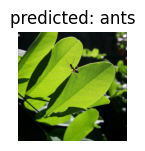

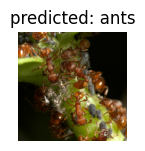

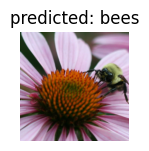

In [22]:
visualize_model(model_ft)